# Train & EDA

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')
from utils import basic_report, TARGET

train_df = pd.read_csv('/content/train.csv')
basic_report(train_df)
train_df.head()

shape: (1040, 35)

nulls:
 Series([], dtype: int64)

dupes: 1

dtypes:
 Age                         float64
Attrition                    object
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome                object
MonthlyRate                   int64
NumCompaniesWorked          float64
Over18                       object
OverTime                     object
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction    

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,36.0,No,Travel_Rarely,164,Sales,2,2,Medical,1,513,...,2,80,2.0,10.0,2.0,3,10.0,9.0,7.5,0.0
1,29.0,No,Travel_Rarely,153,Research & Development,15,2,Life Sciences,1,15,...,4,80,0.0,10.0,3.0,3,9.0,5.0,0.0,8.0
2,41.0,No,Non-Travel,552,Human Resources,4,3,Human Resources,1,1722,...,2,80,1.0,10.0,4.0,3,3.0,2.0,1.0,2.0
3,32.0,No,Travel_Rarely,929,Sales,10,3,Marketing,1,722,...,4,80,0.0,10.0,2.0,2,10.0,7.0,0.0,8.0
4,35.0,Yes,Travel_Rarely,1204,Sales,4,3,Technical Degree,1,1100,...,1,80,0.0,9.0,2.0,3,8.0,7.0,4.0,7.0


# Target Balance

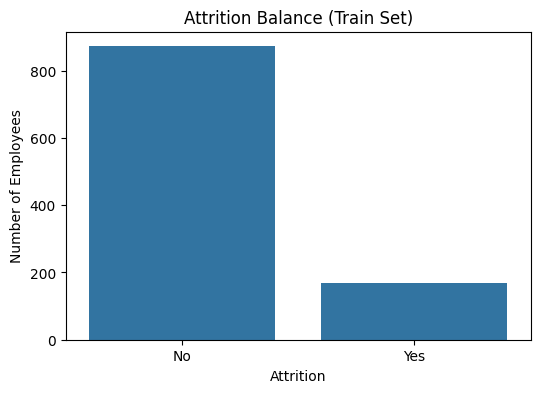

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x=TARGET, data=train_df)

plt.title('Attrition Balance (Train Set)')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.savefig('attrition_balance.png', bbox_inches='tight')
plt.show()

# Attrition by key categorical features

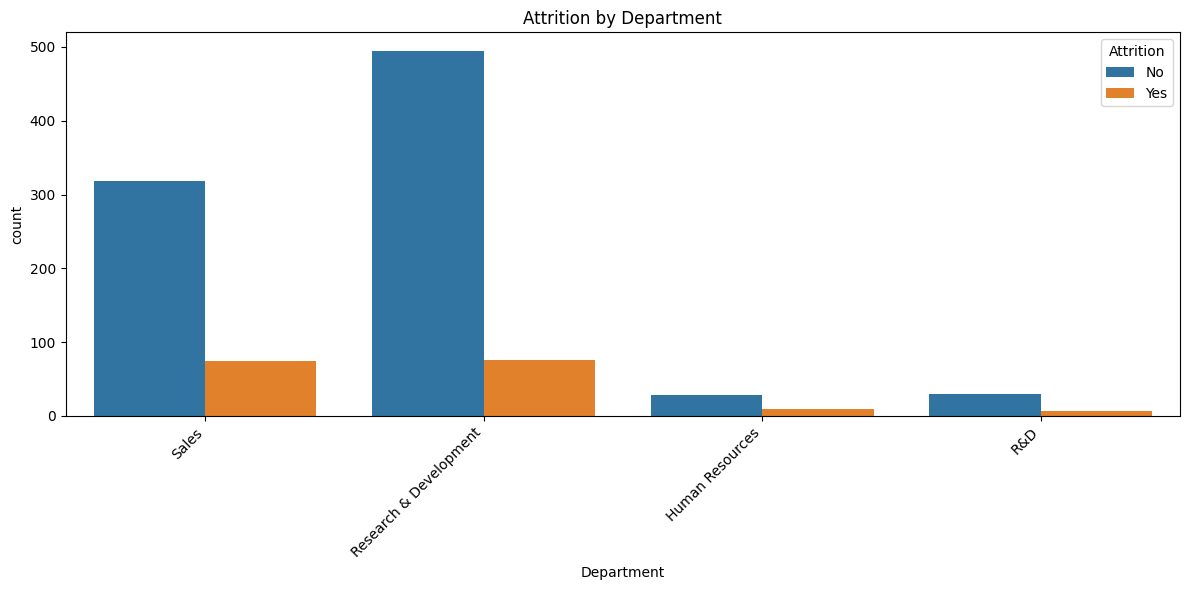

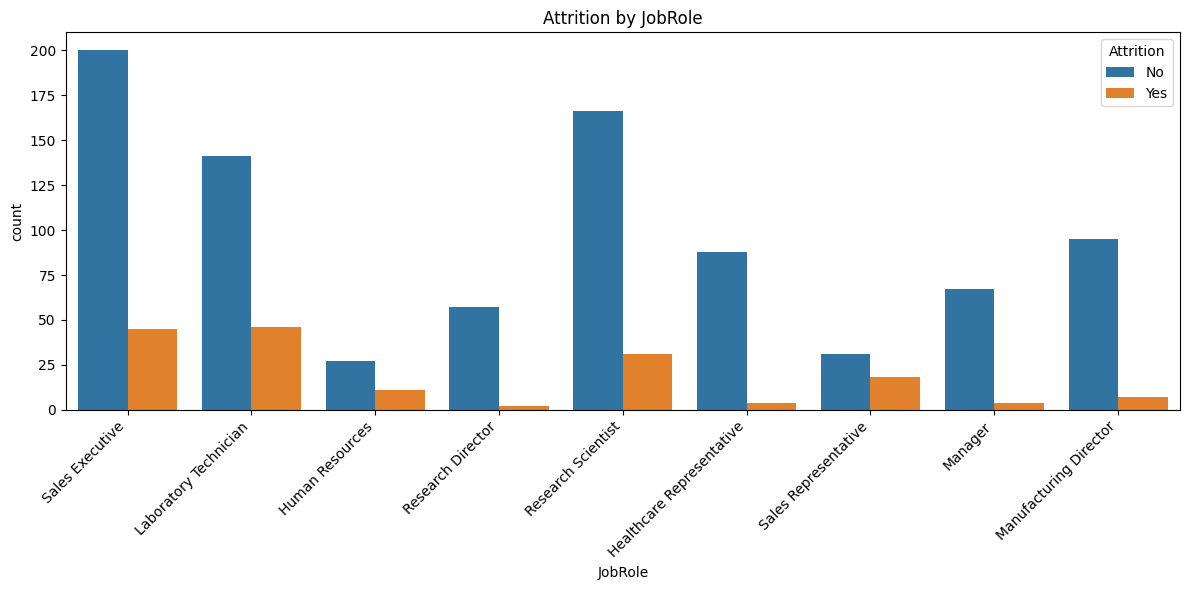

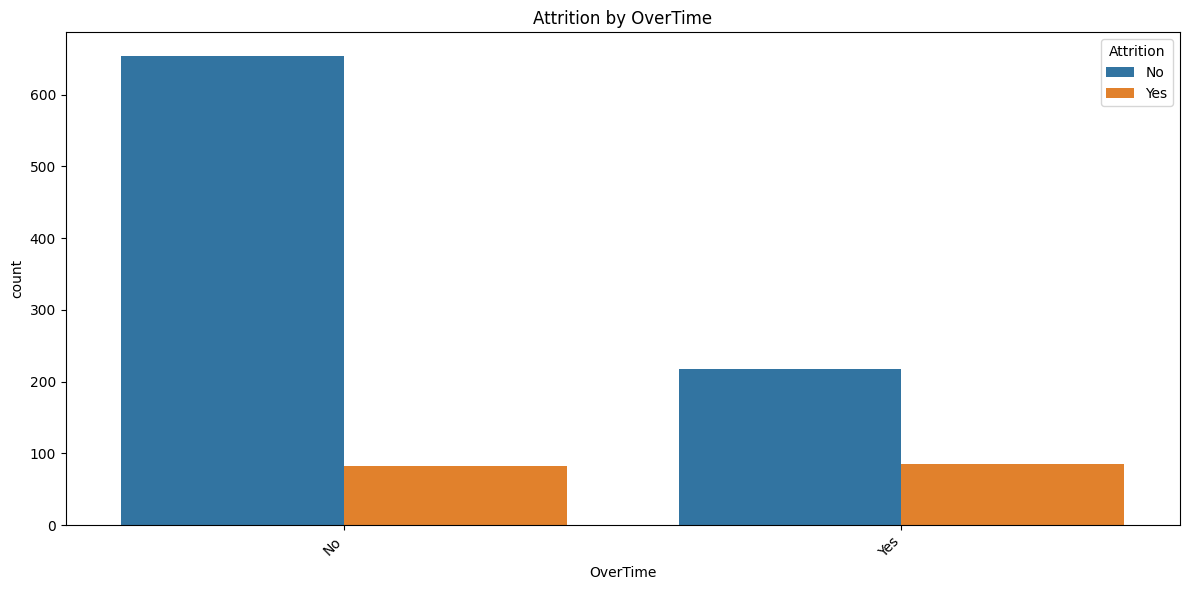

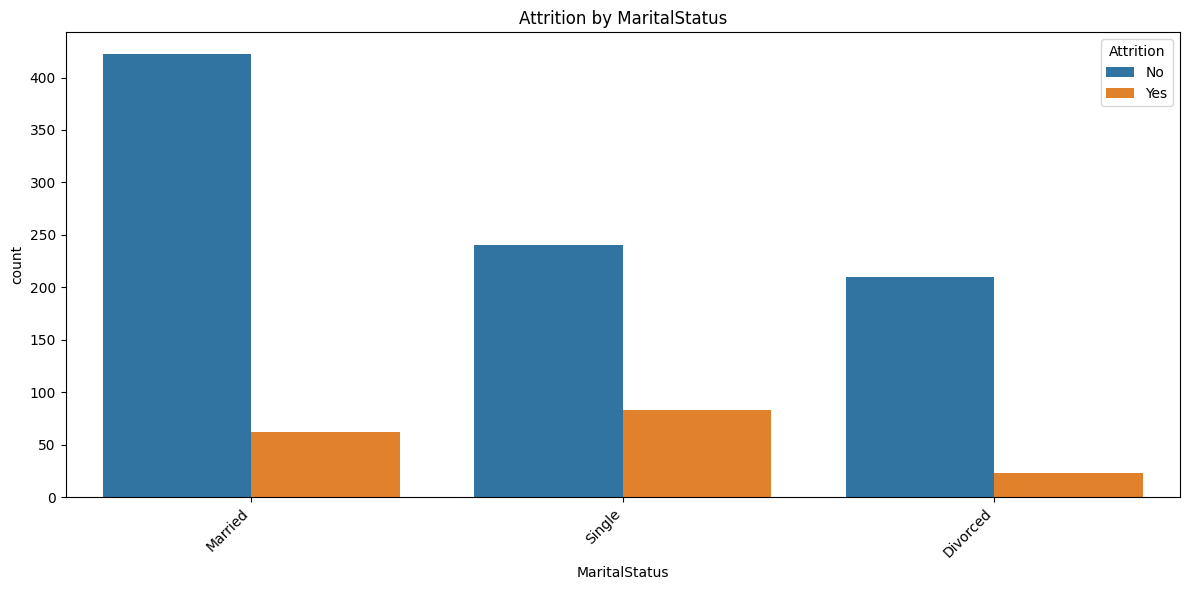

In [20]:
cat_features = [c for c in ['Department', 'JobRole', 'OverTime', 'MaritalStatus'] if c in train_df.columns]

for col in cat_features:
  plt.figure(figsize=(12,6))
  sns.countplot(x=col, hue=TARGET, data=train_df)
  plt.title(f'Attrition by {col}')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.savefig(f'{col}_attrition.png', dpi=300)
  plt.show()
    # plt.figure(figsize=(8,4))
    # sns.countplot(x=col, hue=TARGET, data=train_df)
    # plt.title(f'Attrition by {col}')
    # plt.xticks(rotation=45)
    # plt.savefig(f'{col}_attrition.png', bbox_inches='tight')
    # plt.show()

# correlation heatmap (numeric features)

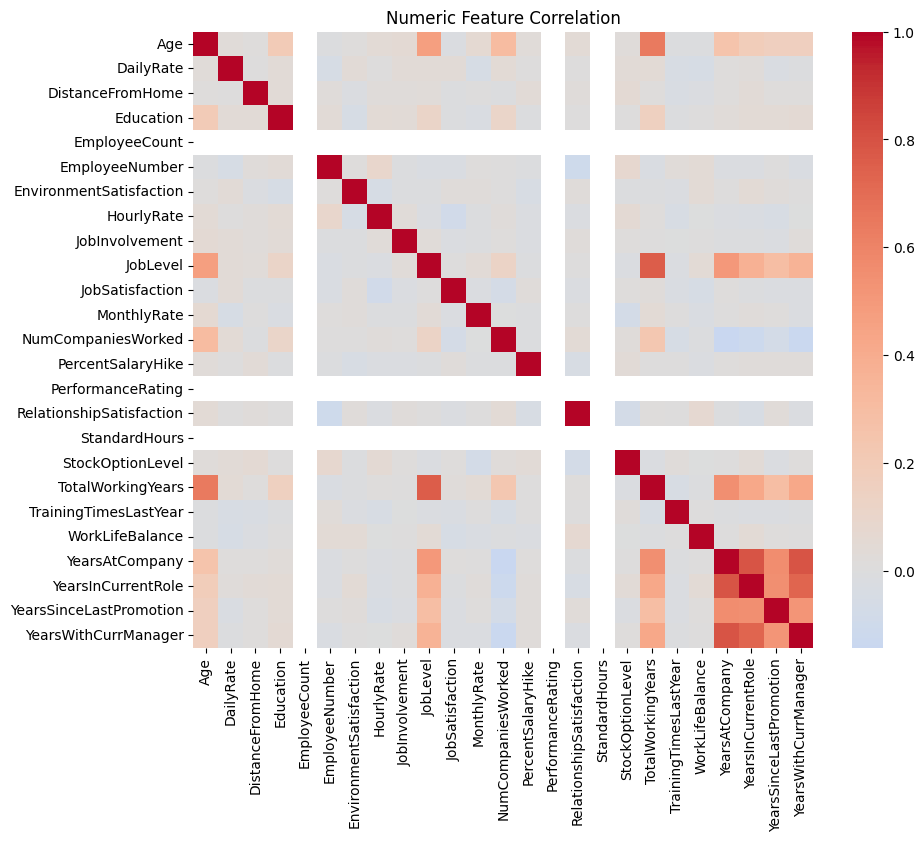

In [21]:
num_df = train_df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0)
plt.title('Numeric Feature Correlation')
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [22]:
train_df["MonthlyIncome"].head(10)

,MonthlyIncome
0,"$7,596.00"
1,"$4,193.00"
2,6430
3,5396
4,9582
5,19049
6,4285
7,"$6,962.00"
8,9439
9,10883


In [23]:
# Clean MonthlyIncome
train_df["MonthlyIncome"] = (train_df["MonthlyIncome"] .astype(str) .str.replace("$", "", regex=False) .str.replace(",", "", regex=False))
train_df["MonthlyIncome"] = pd.to_numeric(train_df["MonthlyIncome"])
train_df["MonthlyIncome"] = pd.to_numeric(train_df["MonthlyIncome"])

In [24]:
df = train_df.copy()
df[TARGET] = df[TARGET].map({'Yes': 1, 'No': 0})

In [25]:
df.select_dtypes(include="object").columns.tolist()

['BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [26]:
df['BusinessTravel'].unique()

array(['Travel_Rarely', 'Non-Travel', 'Travel_Frequently'], dtype=object)

In [27]:
df['Over18'].unique()

array(['Y'], dtype=object)

In [28]:
df["Over18"].value_counts()

,count
Over18,
Y,1040


In [29]:
df.drop(columns=["Over18"], inplace=True)

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["OverTime"] = le.fit_transform(df["OverTime"])

In [31]:
df = pd.get_dummies(df, columns=["BusinessTravel", "Department", "EducationField", "JobRole", "MaritalStatus"], drop_first=True)

In [32]:
X_train = df.drop(columns=[TARGET])
y_train = df[TARGET]

In [33]:
from sklearn.ensemble import RandomForestClassifier
import joblib
model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
joblib.dump(model, 'attrition_model.pkl')
joblib.dump(list(X_train.columns), 'model_columns.pkl')
print("Model saved successfully!")

Model saved successfully!


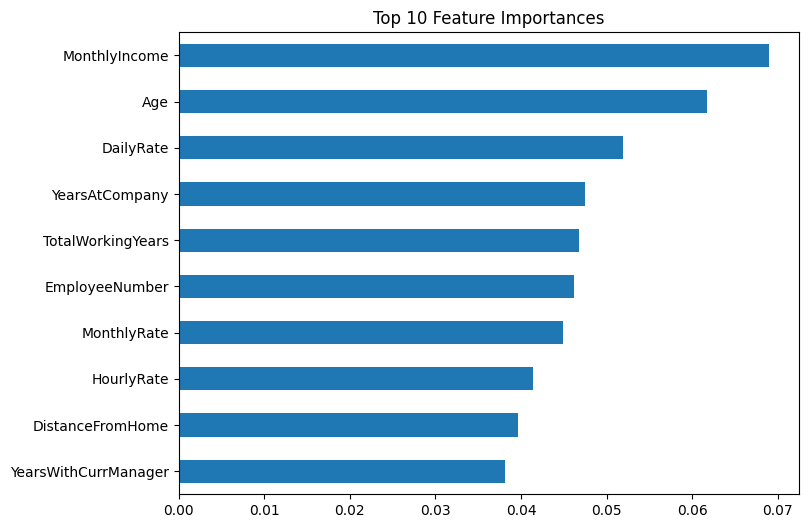

In [34]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances')
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()